In [1]:
import gdown
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_id = '13N3wX7ULgh-uYw6GAMWm0eVq59GwcvNo'
url = f'https://drive.google.com/uc?id={file_id}'
gdown.download(url, 'Dataset Covid19.csv', quiet=False)

df = pd.read_csv('Dataset Covid19.csv')

df_prov = df[df['Location Level'] == 'Province'].copy()

df_wilayah = df_prov.sort_values('Date').groupby('Location').last().reset_index()

df_wilayah['Rasio Kematian (%)'] = (df_wilayah['Total Deaths'] / df_wilayah['Total Cases']) * 100
df_wilayah['Rasio Kesembuhan (%)'] = (df_wilayah['Total Recovered'] / df_wilayah['Total Cases']) * 100

print("Dataset berhasil diunduh dan diproses!")
df_wilayah.head()

Downloading...
From: https://drive.google.com/uc?id=13N3wX7ULgh-uYw6GAMWm0eVq59GwcvNo
To: /content/Dataset Covid19.csv
100%|██████████| 7.50M/7.50M [00:00<00:00, 36.7MB/s]


Dataset berhasil diunduh dan diproses!


,Location,Date,Location ISO Code,New Cases,New Deaths,New Recovered,New Active Cases,Total Cases,Total Deaths,Total Recovered,...,Total Cases per Million,New Deaths per Million,Total Deaths per Million,Total Deaths per 100rb,Case Fatality Rate,Case Recovered Rate,Growth Factor of New Cases,Growth Factor of New Deaths,Rasio Kematian (%),Rasio Kesembuhan (%)
0,Aceh,9/9/2022,ID-AC,10,0,13,-3,43999,2223,41681,...,8385.14,0.00,423.65,42.36,5.05%,94.73%,0.71,1.0,5.052388,94.731698
1,Bali,9/9/2022,ID-BA,36,1,103,-68,166718,4726,161440,...,39542.51,0.24,1120.92,112.09,2.83%,96.83%,0.67,0.8,2.834727,96.834175
2,Banten,9/9/2022,ID-BT,316,0,1603,-1287,333014,2949,327558,...,31057.86,0.00,275.03,27.50,0.89%,98.36%,0.95,1.0,0.885548,98.361630
3,Bengkulu,9/9/2022,ID-BE,1,0,0,1,29149,522,28606,...,14577.86,0.00,261.06,26.11,1.79%,98.14%,0.33,1.0,1.790799,98.137157
4,DKI Jakarta,9/9/2022,ID-JK,1166,2,2146,-982,1408154,15505,1381349,...,129829.91,0.18,1429.54,142.95,1.10%,98.10%,0.88,2.0,1.101087,98.096444


## 1. Statistik Deskriptif Atribut Numerik (Total & Rasio per Wilayah)
Menampilkan rata-rata, standar deviasi, nilai minimum, nilai maksimum, Q1 (25%), Q2 (50%/median), dan Q3 (75%) dari total kasus, kematian, kesembuhan, serta rasionya per wilayah.

In [2]:
cols_target = ['Total Cases', 'Total Deaths', 'Total Recovered', 'Rasio Kematian (%)', 'Rasio Kesembuhan (%)']
numeric_stats = df_wilayah[cols_target].describe().loc[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
numeric_stats.rename(index={'25%': 'Q1', '50%': 'Q2 (Median)', '75%': 'Q3'}, inplace=True)
numeric_stats

,Total Cases,Total Deaths,Total Recovered,Rasio Kematian (%),Rasio Kesembuhan (%)
mean,1.878803e+05,4642.264706,1.821968e+05,2.586962,97.108181
std,3.162394e+05,7964.023992,3.079068e+05,1.215854,1.164103
min,1.395000e+04,295.000000,1.343300e+04,0.885548,94.045109
Q1,3.996625e+04,867.250000,3.865100e+04,1.742400,96.899961
Q2 (Median),6.848250e+04,1810.000000,6.664450e+04,2.371370,97.456595
Q3,1.571478e+05,3982.750000,1.530065e+05,2.837047,98.044356
max,1.408154e+06,33478.000000,1.381349e+06,5.550473,98.385240


## 2. 10 Record Pertama Atribut Numerik per Wilayah
Menampilkan 10 baris pertama data statistik total dan rasio kematian/kesembuhan per wilayah.

In [3]:
df_wilayah[['Location'] + cols_target].head(10)

,Location,Total Cases,Total Deaths,Total Recovered,Rasio Kematian (%),Rasio Kesembuhan (%)
0,Aceh,43999,2223,41681,5.052388,94.731698
1,Bali,166718,4726,161440,2.834727,96.834175
2,Banten,333014,2949,327558,0.885548,98.361630
3,Bengkulu,29149,522,28606,1.790799,98.137157
4,DKI Jakarta,1408154,15505,1381349,1.101087,98.096444
5,Daerah Istimewa Yogyakarta,224214,5927,217560,2.643457,97.032299
6,Gorontalo,13950,487,13433,3.491039,96.293907
7,Jambi,38622,889,37641,2.301797,97.459997
8,Jawa Barat,1172165,15936,1142467,1.359536,97.466398
9,Jawa Tengah,635951,33478,601246,5.264242,94.542819


## 3. Informasi Struktur Dataset Wilayah
Menampilkan jumlah total wilayah (baris), jumlah atribut (kolom), daftar nama atribut, serta jumlah atribut numerik.

In [4]:
num_records = len(df_wilayah)
num_attributes = df_wilayah.shape[1]
attribute_names = df_wilayah.columns.tolist()
num_numeric_attributes = len(df_wilayah.select_dtypes(include=['number']).columns)

print(f"Jumlah Wilayah (Record)    : {num_records}")
print(f"Jumlah Atribut              : {num_attributes}")
print(f"Nama-nama Atribut           : {attribute_names}")
print(f"Jumlah Atribut Tipe Angka   : {num_numeric_attributes}")

Jumlah Wilayah (Record)    : 34
Jumlah Atribut              : 40
Nama-nama Atribut           : ['Location', 'Date', 'Location ISO Code', 'New Cases', 'New Deaths', 'New Recovered', 'New Active Cases', 'Total Cases', 'Total Deaths', 'Total Recovered', 'Total Active Cases', 'Location Level', 'City or Regency', 'Province', 'Country', 'Continent', 'Island', 'Time Zone', 'Special Status', 'Total Regencies', 'Total Cities', 'Total Districts', 'Total Urban Villages', 'Total Rural Villages', 'Area (km2)', 'Population', 'Population Density', 'Longitude', 'Latitude', 'New Cases per Million', 'Total Cases per Million', 'New Deaths per Million', 'Total Deaths per Million', 'Total Deaths per 100rb', 'Case Fatality Rate', 'Case Recovered Rate', 'Growth Factor of New Cases', 'Growth Factor of New Deaths', 'Rasio Kematian (%)', 'Rasio Kesembuhan (%)']
Jumlah Atribut Tipe Angka   : 28


## 4. Jumlah Label (Unique Value) Atribut Tipe Object
Menampilkan jumlah label atau variasi nilai unik untuk setiap atribut kategorikal di tingkat wilayah.

In [5]:
object_cols = df_wilayah.select_dtypes(include=['object']).columns

for col in object_cols:
    print(f"Atribut '{col}': {df_wilayah[col].nunique()} label unik")
    print(df_wilayah[col].value_counts())
    print("-" * 50)

Atribut 'Location': 34 label unik
Location
Aceh                          1
Bali                          1
Banten                        1
Bengkulu                      1
DKI Jakarta                   1
Daerah Istimewa Yogyakarta    1
Gorontalo                     1
Jambi                         1
Jawa Barat                    1
Jawa Tengah                   1
Jawa Timur                    1
Kalimantan Barat              1
Kalimantan Selatan            1
Kalimantan Tengah             1
Kalimantan Timur              1
Kalimantan Utara              1
Kepulauan Bangka Belitung     1
Kepulauan Riau                1
Lampung                       1
Maluku                        1
Maluku Utara                  1
Nusa Tenggara Barat           1
Nusa Tenggara Timur           1
Papua                         1
Papua Barat                   1
Riau                          1
Sulawesi Barat                1
Sulawesi Selatan              1
Sulawesi Tengah               1
Sulawesi Tenggara            

## 5. Visualisasi Total dan Rasio Kematian/Kesembuhan per Wilayah
1. Grafik Batang (Bar Chart): Menampilkan 10 Wilayah dengan Rasio Kematian (%) Tertinggi.
2. Histogram: Memvisualisasikan distribusi Rasio Kesembuhan (%) di seluruh Wilayah.

/tmp/ipykernel_3212/70154189.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_kematian, x='Rasio Kematian (%)', y='Location', ax=axes[0], palette='Reds_r')


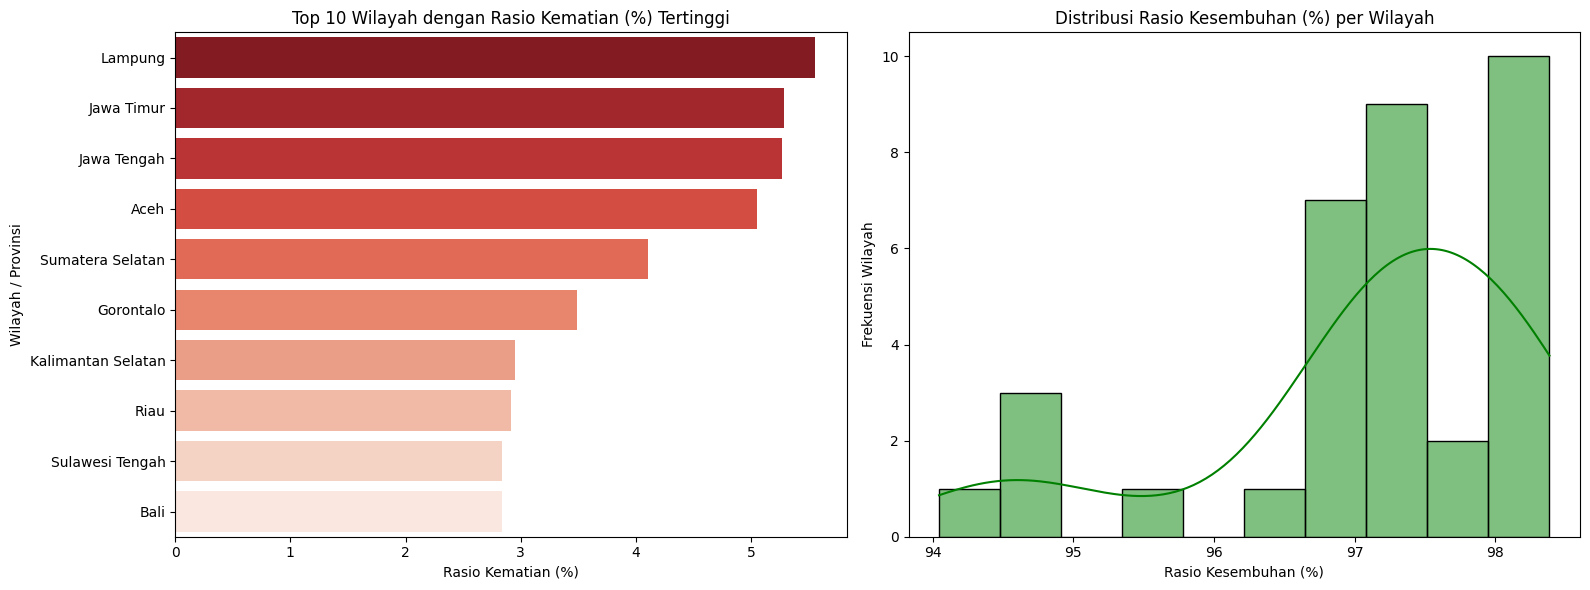

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10_kematian = df_wilayah.sort_values(by='Rasio Kematian (%)', ascending=False).head(10)
sns.barplot(data=top10_kematian, x='Rasio Kematian (%)', y='Location', ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 10 Wilayah dengan Rasio Kematian (%) Tertinggi')
axes[0].set_xlabel('Rasio Kematian (%)')
axes[0].set_ylabel('Wilayah / Provinsi')

sns.histplot(df_wilayah['Rasio Kesembuhan (%)'], kde=True, ax=axes[1], color='green', bins=10)
axes[1].set_title('Distribusi Rasio Kesembuhan (%) per Wilayah')
axes[1].set_xlabel('Rasio Kesembuhan (%)')
axes[1].set_ylabel('Frekuensi Wilayah')

plt.tight_layout()
plt.show()

## 6. Heatmap Korelasi Kasus, Kematian, Kesembuhan, dan Rasionya
Menampilkan matriks korelasi antar variabel total dan rasio per wilayah menggunakan Heatmap Seaborn.

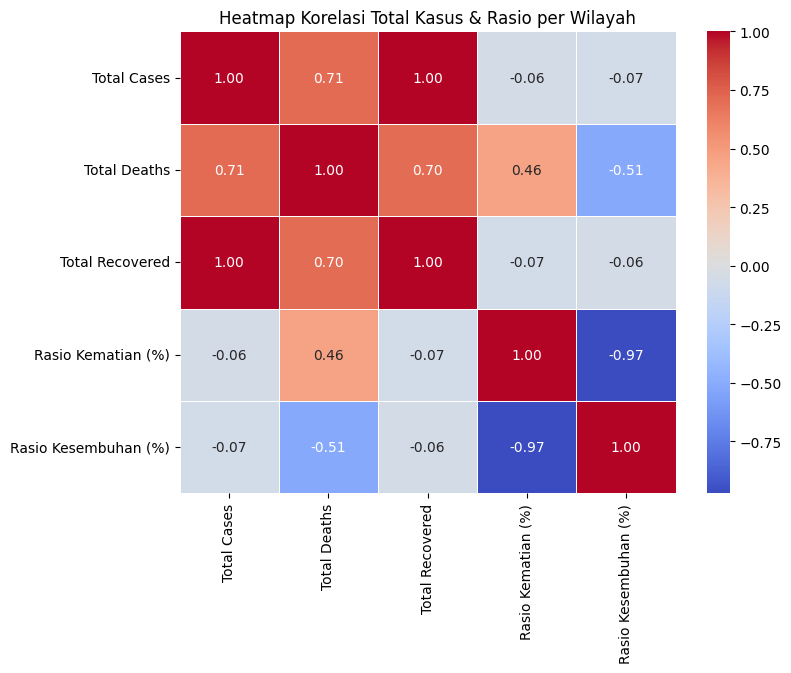

In [7]:
plt.figure(figsize=(8, 6))
correlation_matrix = df_wilayah[cols_target].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Total Kasus & Rasio per Wilayah')
plt.show()